In [1]:
# Cell 1 — Load, harmonize, and validate finalized 30/60/120/180-s results
from __future__ import annotations

import os
import re
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-ntsa-robust')

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats


def locate_phase1(start: Path) -> Path:
    marker = Path('results/simplex_projection/summary/processed_simplex_summary.csv')
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / marker).is_file():
            return candidate
        nested = candidate / 'phase1'
        if (nested / marker).is_file():
            return nested
    raise FileNotFoundError('Could not locate phase1.')


def require(condition: bool, message: str) -> None:
    if not condition:
        raise ValueError(message)


def normalize_session(series: pd.Series) -> pd.Series:
    extracted = series.astype(str).str.extract(r'(\d+)$', expand=False)
    require(extracted.notna().all(), 'Unrecognized session identifier.')
    return pd.to_numeric(extracted, errors='raise').astype(int)


def strict_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    values = series.astype(str).str.strip().str.casefold()
    truthy = {'true', '1', '1.0', 'yes', 'pass', 'included'}
    falsy = {'false', '0', '0.0', 'no', 'fail', 'excluded'}
    require(values.isin(truthy | falsy).all(), f'Invalid Boolean values in {series.name}.')
    return values.isin(truthy)


PHASE1_DIR = locate_phase1(Path.cwd())
OUTPUT_DIR = PHASE1_DIR / 'outputs' / 'robust_window'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DURATIONS = (30, 60, 120, 180)
SENSITIVITY_DURATIONS = (30, 120, 180)
PRIMARY_DURATION = 60
STATES = ('Awake', 'Drowsy')
METRICS = ('Mean_CC', 'Mean_NRMSE', 'DET', 'LLE')
EXPECTED_SIGN = {'Mean_CC': -1, 'Mean_NRMSE': 1, 'DET': -1, 'LLE': -1}
SOURCE_DOMAIN = {'Mean_CC': 'Prediction', 'Mean_NRMSE': 'Prediction', 'DET': 'RQA', 'LLE': 'LLE'}
LLE_R2_THRESHOLD = 0.90

# Prediction: use the finalized saved hierarchy. For 60/120/180 s this is
# the mean across 18 horizon-specific window medians. The 30-s file already
# stores each window's 18-horizon Mean_CC/Mean_NRMSE, which are then median-
# aggregated within session × state as required for the lower-bound analysis.
prediction_old_path = PHASE1_DIR / 'results/simplex_projection/summary/processed_simplex_summary.csv'
prediction_30_path = PHASE1_DIR / 'results/30s_window/simplex/processed_simplex_window_results_30s.csv'
prediction_old = pd.read_csv(prediction_old_path)
prediction_30 = pd.read_csv(prediction_30_path)
old_prediction_required = {'session', 'state', 'representation', 'window_size_s', 'horizon_seconds', 'median_cc', 'median_nrmse', 'n_windows'}
new_prediction_required = {'session', 'state', 'duration_s', 'window_id', 'Mean_CC', 'Mean_NRMSE', 'valid'}
require(old_prediction_required.issubset(prediction_old.columns), 'Finalized prediction summary schema is incomplete.')
require(new_prediction_required.issubset(prediction_30.columns), '30-s prediction schema is incomplete.')
prediction_old = prediction_old.loc[prediction_old['representation'].astype(str).str.casefold().eq('processed') & prediction_old['window_size_s'].isin(DURATIONS[1:]) & prediction_old['state'].isin(STATES)].copy()
prediction_30 = prediction_30.loc[prediction_30['duration_s'].eq(30) & prediction_30['state'].isin(STATES)].copy()
prediction_old['session'] = normalize_session(prediction_old['session'])
prediction_30['session'] = normalize_session(prediction_30['session'])
require(not prediction_old.duplicated(['session', 'state', 'window_size_s', 'horizon_seconds']).any(), 'Duplicate finalized prediction summary rows.')
require(not prediction_30.duplicated(['session', 'state', 'duration_s', 'window_id']).any(), 'Duplicate 30-s prediction window rows.')
prediction_30_valid = strict_bool(prediction_30['valid'])
require(prediction_30_valid.all(), 'A 30-s prediction window is marked invalid.')
require(np.isfinite(prediction_30[['Mean_CC', 'Mean_NRMSE']].to_numpy(float)).all(), 'Non-finite 30-s prediction metric.')
horizon_grid = prediction_old.groupby('window_size_s')['horizon_seconds'].apply(lambda values: tuple(sorted(values.unique())))
require(horizon_grid.nunique() == 1 and len(horizon_grid.iloc[0]) == 18, 'Finalized prediction horizon grid is not identical across 60/120/180 s.')
prediction_old_cells = prediction_old.groupby(['session', 'state', 'window_size_s'])
require(prediction_old_cells['horizon_seconds'].nunique().eq(18).all(), 'A finalized prediction cell has incomplete horizons.')
require(prediction_old_cells['n_windows'].nunique().eq(1).all(), 'Finalized prediction window count varies across horizons.')
prediction_old_state = prediction_old_cells.agg(Mean_CC=('median_cc', 'mean'), Mean_NRMSE=('median_nrmse', 'mean'), n_windows=('n_windows', 'first')).reset_index().rename(columns={'window_size_s': 'duration_s'})
prediction_30_state = prediction_30.groupby(['session', 'state', 'duration_s'], as_index=False).agg(Mean_CC=('Mean_CC', 'median'), Mean_NRMSE=('Mean_NRMSE', 'median'), n_windows=('window_id', 'size'))
prediction_state = pd.concat([prediction_30_state, prediction_old_state], ignore_index=True)
prediction_long = prediction_state.melt(id_vars=['session', 'state', 'duration_s', 'n_windows'], value_vars=['Mean_CC', 'Mean_NRMSE'], var_name='metric', value_name='value')

# RQA: combine window-level Processed results, retain valid rows, and median-aggregate DET.
rqa_old_path = PHASE1_DIR / 'results/rqa/rqa_window_level.csv'
rqa_30_path = PHASE1_DIR / 'results/30s_window/rqa/rqa_window_level_30s.csv'
rqa_old = pd.read_csv(rqa_old_path)
rqa_30 = pd.read_csv(rqa_30_path)
rqa_required = {'session', 'state', 'representation', 'window_size', 'window_id', 'target_rr', 'DET'}
require(rqa_required.issubset(rqa_old.columns) and rqa_required.issubset(rqa_30.columns), 'RQA schema is incomplete.')
rqa_old = rqa_old.loc[rqa_old['representation'].astype(str).str.casefold().eq('processed') & rqa_old['window_size'].isin(DURATIONS[1:]) & rqa_old['state'].isin(STATES)].copy()
rqa_30 = rqa_30.loc[rqa_30['window_size'].eq(30) & rqa_30['state'].isin(STATES)].copy()
rqa_old['session'] = normalize_session(rqa_old['session'])
rqa_30['session'] = normalize_session(rqa_30['session'])
require(not rqa_old.duplicated(['session', 'state', 'window_size', 'window_id']).any(), 'Duplicate finalized RQA window rows.')
require(not rqa_30.duplicated(['session', 'state', 'window_size', 'window_id']).any(), 'Duplicate 30-s RQA window rows.')
require(strict_bool(rqa_30['valid']).all(), 'A 30-s RQA row is invalid.')
rqa = pd.concat([rqa_30, rqa_old], ignore_index=True, sort=False)
require(set(rqa['window_size'].unique()) == set(DURATIONS), 'RQA durations are incomplete.')
require(np.isfinite(rqa['DET']).all() and np.allclose(rqa['target_rr'], 0.02), 'RQA metric/config validation failed.')
rqa_state = rqa.groupby(['session', 'state', 'window_size'], as_index=False).agg(value=('DET', 'median'), n_windows=('window_id', 'size')).rename(columns={'window_size': 'duration_s'})
rqa_state['metric'] = 'DET'

# LLE: combine all saved window rows and reapply only the finalized primary QC.
lle_old_dir = PHASE1_DIR / 'results/lle/processed'
lle_old_paths = sorted(lle_old_dir.glob('session_*_processed_rosenstein_lle.csv'))
lle_30_path = PHASE1_DIR / 'results/30s_window/lle/all_sessions_processed_rosenstein_lle_30s.csv'
require(len(lle_old_paths) == 20, f'Expected 20 finalized LLE files; found {len(lle_old_paths)}.')
lle_old = pd.concat([pd.read_csv(path) for path in lle_old_paths], ignore_index=True)
lle_30 = pd.read_csv(lle_30_path)
lle_required = {'session', 'state', 'window_size_s', 'window_id', 'representation', 'm', 'tau_s', 'fit_start_s', 'fit_end_s', 'lle_1_per_s', 'fit_r2', 'analysis_included', 'signal_finite', 'valid'}
require(lle_required.issubset(lle_old.columns) and lle_required.issubset(lle_30.columns), 'LLE schema is incomplete.')
lle_old = lle_old.loc[lle_old['representation'].astype(str).str.casefold().eq('processed') & lle_old['window_size_s'].isin(DURATIONS[1:]) & lle_old['state'].isin(STATES)].copy()
lle_30 = lle_30.loc[lle_30['window_size_s'].eq(30) & lle_30['state'].isin(STATES)].copy()
lle_old['session'] = normalize_session(lle_old['session'])
lle_30['session'] = normalize_session(lle_30['session'])
require(not lle_old.duplicated(['session', 'state', 'window_size_s', 'window_id']).any(), 'Duplicate finalized LLE window rows.')
require(not lle_30.duplicated(['session', 'state', 'window_size_s', 'window_id']).any(), 'Duplicate 30-s LLE window rows.')
lle = pd.concat([lle_30, lle_old], ignore_index=True, sort=False)
require(set(lle['window_size_s'].unique()) == set(DURATIONS), 'LLE durations are incomplete.')
require(np.allclose(lle['m'], 8) and np.allclose(lle['tau_s'], 0.16), 'LLE reconstruction parameters changed.')
require(np.allclose(lle['fit_start_s'], 0.80) and np.allclose(lle['fit_end_s'], 1.30), 'LLE fit interval changed.')
lle_finite = np.isfinite(lle[['lle_1_per_s', 'fit_r2']].to_numpy(float)).all(axis=1)
lle_primary_qc = strict_bool(lle['analysis_included']) & strict_bool(lle['signal_finite']) & lle_finite & lle['fit_r2'].ge(LLE_R2_THRESHOLD)
require(strict_bool(lle['valid']).eq(lle_primary_qc).all(), 'Saved LLE validity differs from frozen R2 >= 0.90 QC.')
lle_valid = lle.loc[lle_primary_qc].copy()
lle_state = lle_valid.groupby(['session', 'state', 'window_size_s'], as_index=False).agg(value=('lle_1_per_s', 'median'), n_windows=('window_id', 'size')).rename(columns={'window_size_s': 'duration_s'})
lle_state['metric'] = 'LLE'

session_state_long = pd.concat([prediction_long, rqa_state[['session', 'state', 'duration_s', 'n_windows', 'metric', 'value']], lle_state[['session', 'state', 'duration_s', 'n_windows', 'metric', 'value']]], ignore_index=True)
require(set(session_state_long['duration_s'].unique()) == set(DURATIONS), 'Harmonized durations are not exactly 30/60/120/180 s.')
require(set(session_state_long['state'].unique()) == set(STATES), 'Unexpected state labels after harmonization.')
require(not session_state_long.duplicated(['session', 'state', 'duration_s', 'metric']).any(), 'Duplicate harmonized session-state metric rows.')
require(np.isfinite(session_state_long['value']).all(), 'Non-finite harmonized session-state values.')

prediction_counts = prediction_state.melt(id_vars=['session', 'state', 'duration_s'], value_vars=['Mean_CC', 'Mean_NRMSE'], var_name='metric', value_name='_value').merge(prediction_state[['session', 'state', 'duration_s', 'n_windows']], on=['session', 'state', 'duration_s'], validate='many_to_one').groupby(['metric', 'duration_s', 'state'], as_index=False)['n_windows'].sum()
rqa_counts = rqa.groupby(['window_size', 'state'], as_index=False).size().rename(columns={'window_size': 'duration_s', 'size': 'n_windows'}).assign(metric='DET')
lle_counts = lle.assign(qc_valid=lle_primary_qc).loc[lambda frame: frame['qc_valid']].groupby(['window_size_s', 'state'], as_index=False).size().rename(columns={'window_size_s': 'duration_s', 'size': 'n_windows'}).assign(metric='LLE')
valid_window_counts = pd.concat([prediction_counts[['metric', 'duration_s', 'state', 'n_windows']], rqa_counts[['metric', 'duration_s', 'state', 'n_windows']], lle_counts[['metric', 'duration_s', 'state', 'n_windows']]], ignore_index=True)
valid_window_counts = valid_window_counts.sort_values(['metric', 'duration_s', 'state']).reset_index(drop=True)
session_coverage = session_state_long.groupby(['metric', 'duration_s', 'state'])['session'].nunique().rename('n_sessions').reset_index()
coverage_report = valid_window_counts.merge(session_coverage, on=['metric', 'duration_s', 'state'], validate='one_to_one')
session_state_path = OUTPUT_DIR / 'robust_window_session_state_values.csv'
session_state_long.sort_values(['metric', 'duration_s', 'session', 'state']).to_csv(session_state_path, index=False)
print('Loaded finalized results only; no NTSA algorithm was rerun.')
print('Durations={30, 60, 120, 180}; states={Awake, Drowsy}; LLE QC=R2 >= 0.90: PASS')
display(coverage_report)
print(f'Saved: {session_state_path}')

Loaded finalized results only; no NTSA algorithm was rerun.
Durations={30, 60, 120, 180}; states={Awake, Drowsy}; LLE QC=R2 >= 0.90: PASS


,metric,duration_s,state,n_windows,n_sessions
0,DET,30,Awake,1192,20
1,DET,30,Drowsy,610,20
2,DET,60,Awake,596,20
3,DET,60,Drowsy,305,20
4,DET,120,Awake,269,20
5,DET,120,Drowsy,136,20
6,DET,180,Awake,161,20
7,DET,180,Drowsy,77,20
8,LLE,30,Awake,1089,20
9,LLE,30,Drowsy,549,20


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_session_state_values.csv


In [2]:
# Cell 2 — Session-level paired effects and descriptive inference
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20260901
ZERO_TOLERANCE = 1e-12


def bootstrap_median_ci(values: np.ndarray, seed: int) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    require(values.ndim == 1 and len(values) > 0 and np.isfinite(values).all(), 'Invalid bootstrap input.')
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values)))
    medians = np.median(values[indices], axis=1)
    low, high = np.percentile(medians, [2.5, 97.5])
    return float(low), float(high)


def paired_rank_biserial(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    nonzero = values[~np.isclose(values, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method='average')
    positive = float(ranks[nonzero > 0].sum())
    negative = float(ranks[nonzero < 0].sum())
    return (positive - negative) / (positive + negative)


value_wide = session_state_long.pivot(index=['session', 'duration_s', 'metric'], columns='state', values='value').reindex(columns=STATES)
window_wide = session_state_long.pivot(index=['session', 'duration_s', 'metric'], columns='state', values='n_windows').reindex(columns=STATES)
paired_mask = value_wide.notna().all(axis=1)
session_deltas = value_wide.loc[paired_mask].reset_index().rename(columns={'Awake': 'awake', 'Drowsy': 'drowsy'})
session_deltas['delta_drowsy_minus_awake'] = session_deltas['drowsy'] - session_deltas['awake']
paired_windows = window_wide.loc[paired_mask].reset_index().rename(columns={'Awake': 'n_windows_awake', 'Drowsy': 'n_windows_drowsy'})
session_deltas = session_deltas.merge(paired_windows, on=['session', 'duration_s', 'metric'], validate='one_to_one')
session_deltas['source_domain'] = session_deltas['metric'].map(SOURCE_DOMAIN)
session_deltas['expected_sign'] = session_deltas['metric'].map(EXPECTED_SIGN)
session_deltas['in_expected_direction'] = np.sign(session_deltas['delta_drowsy_minus_awake']).eq(session_deltas['expected_sign'])
require(not session_deltas.duplicated(['session', 'duration_s', 'metric']).any(), 'Duplicate paired session effects.')

summary_rows = []
for metric_index, metric in enumerate(METRICS):
    for duration_index, duration in enumerate(DURATIONS):
        group = session_deltas.loc[session_deltas['metric'].eq(metric) & session_deltas['duration_s'].eq(duration)].sort_values('session')
        require(len(group) >= 2, f'Insufficient paired sessions: {metric}, {duration} s.')
        delta = group['delta_drowsy_minus_awake'].to_numpy(float)
        seed = BOOTSTRAP_SEED + metric_index * 100 + duration_index
        ci_low, ci_high = bootstrap_median_ci(delta, seed)
        nonzero = delta[~np.isclose(delta, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)]
        if nonzero.size == 0:
            wilcoxon_statistic, raw_p_value = 0.0, 1.0
        else:
            test = stats.wilcoxon(nonzero, zero_method='wilcox', correction=False, alternative='two-sided', method='auto')
            wilcoxon_statistic, raw_p_value = float(test.statistic), float(test.pvalue)
        summary_rows.append({
            'metric': metric, 'duration_s': duration, 'role': 'primary' if duration == PRIMARY_DURATION else 'sensitivity',
            'n_paired_sessions': len(group), 'awake_session_median': float(group['awake'].median()),
            'drowsy_session_median': float(group['drowsy'].median()), 'median_delta': float(np.median(delta)),
            'ci95_low': ci_low, 'ci95_high': ci_high, 'ci95_width': ci_high - ci_low,
            'bootstrap_resamples': BOOTSTRAP_RESAMPLES, 'bootstrap_seed': seed,
            'wilcoxon_statistic': wilcoxon_statistic, 'raw_p_value': raw_p_value,
            'rank_biserial_r_rb': paired_rank_biserial(delta),
            'n_positive': int(np.count_nonzero(delta > ZERO_TOLERANCE)),
            'n_negative': int(np.count_nonzero(delta < -ZERO_TOLERANCE)),
            'n_zero': int(np.count_nonzero(np.isclose(delta, 0.0, atol=ZERO_TOLERANCE, rtol=0.0))),
        })
duration_statistics = pd.DataFrame(summary_rows)
duration_statistics['expected_sign'] = duration_statistics['metric'].map(EXPECTED_SIGN)
duration_statistics['median_in_expected_direction'] = np.sign(duration_statistics['median_delta']).eq(duration_statistics['expected_sign'])
duration_statistics['ci_excludes_zero'] = (duration_statistics['ci95_low'] > 0) | (duration_statistics['ci95_high'] < 0)
duration_statistics['ci_on_expected_side'] = np.where(duration_statistics['expected_sign'].gt(0), duration_statistics['ci95_low'].gt(0), duration_statistics['ci95_high'].lt(0))
session_delta_path = OUTPUT_DIR / 'robust_window_session_deltas.csv'
statistics_path = OUTPUT_DIR / 'robust_window_summary.csv'
session_deltas.sort_values(['metric', 'duration_s', 'session']).to_csv(session_delta_path, index=False)
duration_statistics.to_csv(statistics_path, index=False)
print('Bootstrap resamples paired session deltas; raw Wilcoxon p-values are descriptive only.')
print('No cross-duration BH-FDR family was created.')
display(duration_statistics)
print(f'Saved: {session_delta_path} and {statistics_path}')

Bootstrap resamples paired session deltas; raw Wilcoxon p-values are descriptive only.
No cross-duration BH-FDR family was created.


,metric,duration_s,role,n_paired_sessions,awake_session_median,drowsy_session_median,median_delta,ci95_low,ci95_high,ci95_width,...,wilcoxon_statistic,raw_p_value,rank_biserial_r_rb,n_positive,n_negative,n_zero,expected_sign,median_in_expected_direction,ci_excludes_zero,ci_on_expected_side
0,Mean_CC,30,sensitivity,20,0.687456,0.646393,-0.014698,-0.071197,-0.003890,0.067308,...,48.0,0.032768,-0.542857,5,15,0,-1,True,True,True
1,Mean_CC,60,primary,20,0.689007,0.663472,-0.033871,-0.059465,-0.004348,0.055117,...,44.0,0.021484,-0.580952,5,15,0,-1,True,True,True
2,Mean_CC,120,sensitivity,20,0.695147,0.670488,-0.027124,-0.049042,-0.015585,0.033457,...,40.0,0.013617,-0.619048,4,16,0,-1,True,True,True
3,Mean_CC,180,sensitivity,20,0.704790,0.678568,-0.042767,-0.051641,-0.013331,0.038310,...,37.0,0.009436,-0.647619,5,15,0,-1,True,True,True
4,Mean_NRMSE,30,sensitivity,20,0.646092,0.680439,0.020275,0.000898,0.055400,0.054502,...,37.0,0.009436,0.647619,14,6,0,1,True,True,True
5,Mean_NRMSE,60,primary,20,0.639154,0.665732,0.029424,0.004651,0.053021,0.048370,...,35.0,0.007296,0.666667,15,5,0,1,True,True,True
6,Mean_NRMSE,120,sensitivity,20,0.624684,0.652512,0.032075,0.019613,0.049531,0.029917,...,36.0,0.008308,0.657143,15,5,0,1,True,True,True
7,Mean_NRMSE,180,sensitivity,20,0.617632,0.644588,0.032095,0.018647,0.046484,0.027837,...,35.0,0.007296,0.666667,15,5,0,1,True,True,True
8,DET,30,sensitivity,20,0.714910,0.698552,-0.016895,-0.031762,0.000208,0.031970,...,41.0,0.015312,-0.609524,6,14,0,-1,True,False,False
9,DET,60,primary,20,0.712615,0.698349,-0.018645,-0.036354,-0.006899,0.029455,...,44.0,0.021484,-0.580952,5,15,0,-1,True,True,True


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_session_deltas.csv and /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_summary.csv


In [3]:
# Cell 3 — Cross-duration direction, common-session sign consistency, and magnitude stability
def format_delta_ci(row: pd.Series) -> str:
    return f"{row['median_delta']:.4f} [{row['ci95_low']:.4f}, {row['ci95_high']:.4f}]"


cross_rows = []
compact_rows = []
for metric in METRICS:
    rows = duration_statistics.loc[duration_statistics['metric'].eq(metric)].set_index('duration_s').loc[list(DURATIONS)]
    signs = np.sign(rows['median_delta'].to_numpy(float))
    direction_preserved = bool(np.all(signs != 0) and len(set(signs)) == 1)
    expected_direction_preserved = bool(rows['median_in_expected_direction'].all())
    delta_matrix = session_deltas.loc[session_deltas['metric'].eq(metric)].pivot(index='session', columns='duration_s', values='delta_drowsy_minus_awake').reindex(columns=DURATIONS)
    common = delta_matrix.dropna(axis=0, how='any')
    n_common = len(common)
    require(n_common > 0, f'No common sessions across four durations for {metric}.')
    same_expected_sign = np.sign(common).eq(EXPECTED_SIGN[metric]).all(axis=1)
    same_sign_count = int(same_expected_sign.sum())
    magnitudes = rows['median_delta'].abs()
    primary_magnitude = float(magnitudes.loc[PRIMARY_DURATION])
    require(primary_magnitude > ZERO_TOLERANCE, f'Primary median effect is zero for {metric}.')
    record = {
        'Metric': metric, 'Direction_preserved': direction_preserved,
        'Expected_direction_preserved': expected_direction_preserved,
        'Same_sign_sessions': same_sign_count, 'n_common': n_common,
        'Absolute_delta_min': float(magnitudes.min()), 'Absolute_delta_max': float(magnitudes.max()),
        'Absolute_delta_range': float(magnitudes.max() - magnitudes.min()),
    }
    for duration in DURATIONS:
        record[f'median_delta_{duration}s'] = float(rows.loc[duration, 'median_delta'])
        record[f'ci95_low_{duration}s'] = float(rows.loc[duration, 'ci95_low'])
        record[f'ci95_high_{duration}s'] = float(rows.loc[duration, 'ci95_high'])
        record[f'abs_ratio_vs_60_{duration}s'] = float(magnitudes.loc[duration] / primary_magnitude)
    cross_rows.append(record)
    compact_rows.append({
        'Metric': metric,
        '30 s Delta [95% CI]': format_delta_ci(rows.loc[30]),
        '60 s Delta [95% CI]': format_delta_ci(rows.loc[60]),
        '120 s Delta [95% CI]': format_delta_ci(rows.loc[120]),
        '180 s Delta [95% CI]': format_delta_ci(rows.loc[180]),
        'Direction preserved': 'Yes' if direction_preserved else 'No',
        'Same-sign sessions': f'{same_sign_count}/{n_common}',
        'n_common': n_common,
    })
cross_duration_summary = pd.DataFrame(cross_rows)
compact_table = pd.DataFrame(compact_rows)
cross_path = OUTPUT_DIR / 'robust_window_cross_duration_summary.csv'
compact_path = OUTPUT_DIR / 'robust_window_final_evidence.csv'
cross_duration_summary.to_csv(cross_path, index=False)
compact_table.to_csv(compact_path, index=False)
display(cross_duration_summary, compact_table)
print(f'Saved: {cross_path} and {compact_path}')

,Metric,Direction_preserved,Expected_direction_preserved,Same_sign_sessions,n_common,Absolute_delta_min,Absolute_delta_max,Absolute_delta_range,median_delta_30s,ci95_low_30s,...,ci95_high_60s,abs_ratio_vs_60_60s,median_delta_120s,ci95_low_120s,ci95_high_120s,abs_ratio_vs_60_120s,median_delta_180s,ci95_low_180s,ci95_high_180s,abs_ratio_vs_60_180s
0,Mean_CC,True,True,12,20,0.014698,0.042767,0.028069,-0.014698,-0.071197,...,-0.004348,1.0,-0.027124,-0.049042,-0.015585,0.800821,-0.042767,-0.051641,-0.013331,1.262671
1,Mean_NRMSE,True,True,13,20,0.020275,0.032095,0.011820,0.020275,0.000898,...,0.053021,1.0,0.032075,0.019613,0.049531,1.090122,0.032095,0.018647,0.046484,1.090784
2,DET,True,True,12,20,0.016895,0.024811,0.007916,-0.016895,-0.031762,...,-0.006899,1.0,-0.020089,-0.039937,-0.013409,1.077470,-0.024811,-0.041645,0.000801,1.330742
3,LLE,True,True,15,20,0.032481,0.049850,0.017369,-0.032481,-0.054879,...,-0.022976,1.0,-0.044214,-0.059098,-0.021612,1.176830,-0.049850,-0.058397,-0.021318,1.326836


,Metric,30 s Delta [95% CI],60 s Delta [95% CI],120 s Delta [95% CI],180 s Delta [95% CI],Direction preserved,Same-sign sessions,n_common
0,Mean_CC,"-0.0147 [-0.0712, -0.0039]","-0.0339 [-0.0595, -0.0043]","-0.0271 [-0.0490, -0.0156]","-0.0428 [-0.0516, -0.0133]",Yes,12/20,20
1,Mean_NRMSE,"0.0203 [0.0009, 0.0554]","0.0294 [0.0047, 0.0530]","0.0321 [0.0196, 0.0495]","0.0321 [0.0186, 0.0465]",Yes,13/20,20
2,DET,"-0.0169 [-0.0318, 0.0002]","-0.0186 [-0.0364, -0.0069]","-0.0201 [-0.0399, -0.0134]","-0.0248 [-0.0416, 0.0008]",Yes,12/20,20
3,LLE,"-0.0325 [-0.0549, -0.0066]","-0.0376 [-0.0537, -0.0230]","-0.0442 [-0.0591, -0.0216]","-0.0498 [-0.0584, -0.0213]",Yes,15/20,20


Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_cross_duration_summary.csv and /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_final_evidence.csv


/tmp/ipykernel_28272/1572058209.py:7: RuntimeWarning: Times New Roman is unavailable; using Liberation Serif.
  warnings.warn(f'Times New Roman is unavailable; using {PLOT_FONT}.', RuntimeWarning, stacklevel=1)


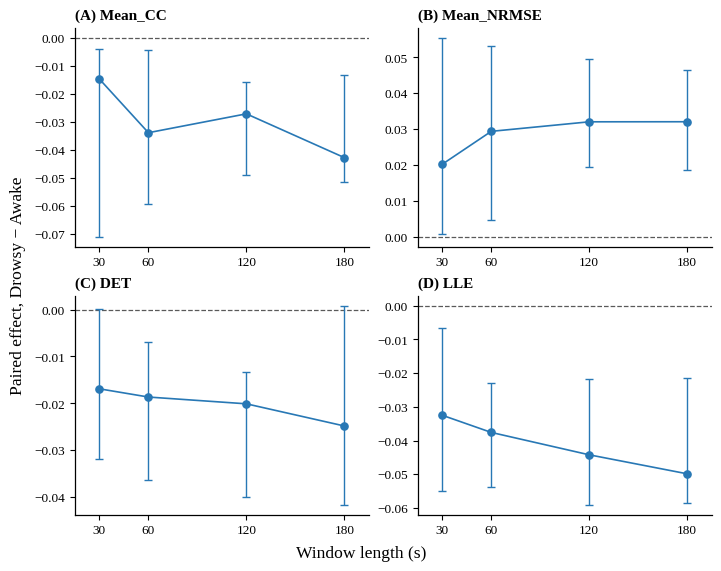

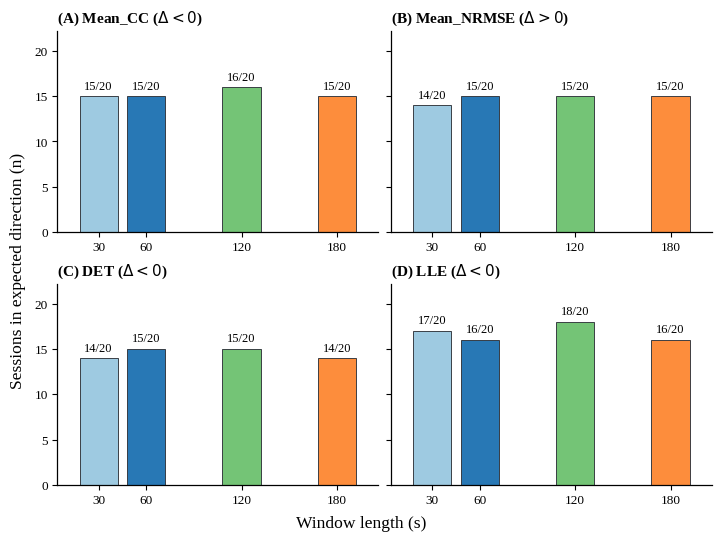

Compact four-duration robustness table:


,Metric,30 s Delta [95% CI],60 s Delta [95% CI],120 s Delta [95% CI],180 s Delta [95% CI],Direction preserved,Same-sign sessions,n_common
0,Mean_CC,"-0.0147 [-0.0712, -0.0039]","-0.0339 [-0.0595, -0.0043]","-0.0271 [-0.0490, -0.0156]","-0.0428 [-0.0516, -0.0133]",Yes,12/20,20
1,Mean_NRMSE,"0.0203 [0.0009, 0.0554]","0.0294 [0.0047, 0.0530]","0.0321 [0.0196, 0.0495]","0.0321 [0.0186, 0.0465]",Yes,13/20,20
2,DET,"-0.0169 [-0.0318, 0.0002]","-0.0186 [-0.0364, -0.0069]","-0.0201 [-0.0399, -0.0134]","-0.0248 [-0.0416, 0.0008]",Yes,12/20,20
3,LLE,"-0.0325 [-0.0549, -0.0066]","-0.0376 [-0.0537, -0.0230]","-0.0442 [-0.0591, -0.0216]","-0.0498 [-0.0584, -0.0213]",Yes,15/20,20


## Four-duration window-size robustness

The 60-s analysis remains primary; 30, 120, and 180 s are sensitivity analyses.

Metrics preserving the predefined effect direction at all four durations: Mean_CC, Mean_NRMSE, DET, LLE.
Metrics not preserving it at all four durations: none.

- Mean_CC: 30-s median Delta=-0.0147 versus 60-s=-0.0339 (absolute magnitude smaller; ratio=0.434); same expected sign across all durations in 12/20 common sessions.
- Mean_NRMSE: 30-s median Delta=0.0203 versus 60-s=0.0294 (absolute magnitude smaller; ratio=0.689); same expected sign across all durations in 13/20 common sessions.
- DET: 30-s median Delta=-0.0169 versus 60-s=-0.0186 (absolute magnitude smaller; ratio=0.906); same expected sign across all durations in 12/20 common sessions.
- LLE: 30-s median Delta=-0.0325 versus 60-s=-0.0376 (absolute magnitude smaller; ratio=0.865); same expected sign across all durations in 15/20 common sessions.

The widest absolute bootstrap interval occurred for Mean_CC at 30 s (width=0.0673 on that metric's native scale).

Direction and magnitude are reported independently of statistical significance. Raw robustness p-values are descriptive and were not added to the primary BH-FDR family.

Saved effect figure: robust_window_primary_metrics.pdf, robust_window_primary_metrics.svg, robust_window_primary_metrics.png (600 dpi)
Saved directional-session figure: robust_window_directional_sessions.pdf, robust_window_directional_sessions.svg, robust_window_directional_sessions.png (600 dpi)
Saved conclusion: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/robust_window/robust_window_conclusion.md


In [4]:
# Cell 4 — Publication figure and concise observed-results summary
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
if 'Times New Roman' in available_fonts:
    PLOT_FONT = 'Times New Roman'
else:
    PLOT_FONT = 'Liberation Serif' if 'Liberation Serif' in available_fonts else 'DejaVu Serif'
    warnings.warn(f'Times New Roman is unavailable; using {PLOT_FONT}.', RuntimeWarning, stacklevel=1)
mpl.rcParams.update({
    'font.family': PLOT_FONT, 'font.size': 10.5, 'axes.labelsize': 11,
    'axes.titlesize': 11, 'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'savefig.transparent': False, 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
})
panel_labels = ('(A)', '(B)', '(C)', '(D)')
fig, axes = plt.subplots(2, 2, figsize=(7.10, 5.60), constrained_layout=True)
for axis, metric, panel in zip(axes.flat, METRICS, panel_labels):
    rows = duration_statistics.loc[duration_statistics['metric'].eq(metric)].set_index('duration_s').loc[list(DURATIONS)]
    estimates = rows['median_delta'].to_numpy(float)
    errors = np.vstack([estimates - rows['ci95_low'].to_numpy(float), rows['ci95_high'].to_numpy(float) - estimates])
    axis.axhline(0.0, color='0.35', linestyle='--', linewidth=0.9, zorder=1)
    axis.errorbar(DURATIONS, estimates, yerr=errors, color='#2878B5', marker='o', markersize=5.2, linewidth=1.2, elinewidth=1.0, capsize=3.0, zorder=3)
    axis.set_xticks(DURATIONS, [str(duration) for duration in DURATIONS])
    axis.set_title(f'{panel} {metric}', loc='left', fontweight='bold')
    axis.margins(x=0.10)
fig.supxlabel('Window length (s)')
fig.supylabel('Paired effect, Drowsy − Awake')
figure_pdf = OUTPUT_DIR / 'robust_window_primary_metrics.pdf'
figure_svg = OUTPUT_DIR / 'robust_window_primary_metrics.svg'
figure_png = OUTPUT_DIR / 'robust_window_primary_metrics.png'
fig.savefig(figure_pdf, bbox_inches='tight')
fig.savefig(figure_svg, bbox_inches='tight')
fig.savefig(figure_png, dpi=600, bbox_inches='tight')
plt.show()

# Separate within-duration replication figure: bars count sessions whose paired
# Delta follows the predefined population-level direction at each duration.
duration_colors = {30: '#9ecae1', 60: '#2878B5', 120: '#74c476', 180: '#fd8d3c'}
direction_fig, direction_axes = plt.subplots(2, 2, figsize=(7.10, 5.30), sharey=True, constrained_layout=True)
max_denominator = int(duration_statistics['n_paired_sessions'].max())
for axis, metric, panel in zip(direction_axes.flat, METRICS, panel_labels):
    rows = duration_statistics.loc[duration_statistics['metric'].eq(metric)].set_index('duration_s').loc[list(DURATIONS)]
    expected_sign = EXPECTED_SIGN[metric]
    count_column = 'n_positive' if expected_sign > 0 else 'n_negative'
    counts = rows[count_column].to_numpy(dtype=int)
    denominators = rows['n_paired_sessions'].to_numpy(dtype=int)
    bars = axis.bar(DURATIONS, counts, width=24, color=[duration_colors[d] for d in DURATIONS], edgecolor='#30343b', linewidth=0.65)
    axis.bar_label(bars, labels=[f'{count}/{denominator}' for count, denominator in zip(counts, denominators)], padding=3, fontsize=9)
    direction_symbol = r'$\Delta < 0$' if expected_sign < 0 else r'$\Delta > 0$'
    axis.set_title(f'{panel} {metric} ({direction_symbol})', loc='left', fontweight='bold')
    axis.set_xticks(DURATIONS, [str(duration) for duration in DURATIONS])
    axis.set_ylim(0, max_denominator + 2.2)
    axis.set_yticks(np.arange(0, max_denominator + 1, 5))
    axis.margins(x=0.08)
direction_fig.supxlabel('Window length (s)')
direction_fig.supylabel('Sessions in expected direction (n)')
direction_pdf = OUTPUT_DIR / 'robust_window_directional_sessions.pdf'
direction_svg = OUTPUT_DIR / 'robust_window_directional_sessions.svg'
direction_png = OUTPUT_DIR / 'robust_window_directional_sessions.png'
direction_fig.savefig(direction_pdf, bbox_inches='tight')
direction_fig.savefig(direction_svg, bbox_inches='tight')
direction_fig.savefig(direction_png, dpi=600, bbox_inches='tight')
plt.show()

preserved_metrics = cross_duration_summary.loc[cross_duration_summary['Expected_direction_preserved'], 'Metric'].tolist()
not_preserved_metrics = cross_duration_summary.loc[~cross_duration_summary['Expected_direction_preserved'], 'Metric'].tolist()
widest = duration_statistics.loc[duration_statistics['ci95_width'].idxmax()]
metric_lines = []
for _, row in cross_duration_summary.iterrows():
    metric = row['Metric']
    delta_30 = row['median_delta_30s']; delta_60 = row['median_delta_60s']
    relation = 'smaller' if abs(delta_30) < abs(delta_60) else ('larger' if abs(delta_30) > abs(delta_60) else 'equal')
    metric_lines.append(
        f"- {metric}: 30-s median Delta={delta_30:.4f} versus 60-s={delta_60:.4f} "
        f"(absolute magnitude {relation}; ratio={row['abs_ratio_vs_60_30s']:.3f}); "
        f"same expected sign across all durations in {int(row['Same_sign_sessions'])}/{int(row['n_common'])} common sessions."
    )
preserved_text = ', '.join(preserved_metrics) if preserved_metrics else 'none'
not_preserved_text = ', '.join(not_preserved_metrics) if not_preserved_metrics else 'none'
conclusion = '\n'.join([
    '## Four-duration window-size robustness', '',
    'The 60-s analysis remains primary; 30, 120, and 180 s are sensitivity analyses.', '',
    f'Metrics preserving the predefined effect direction at all four durations: {preserved_text}.',
    f'Metrics not preserving it at all four durations: {not_preserved_text}.', '',
    *metric_lines, '',
    f"The widest absolute bootstrap interval occurred for {widest['metric']} at {int(widest['duration_s'])} s "
    f"(width={widest['ci95_width']:.4f} on that metric's native scale).", '',
    'Direction and magnitude are reported independently of statistical significance. Raw robustness p-values are descriptive and were not added to the primary BH-FDR family.',
])
conclusion_path = OUTPUT_DIR / 'robust_window_conclusion.md'
conclusion_path.write_text(conclusion + '\n', encoding='utf-8')
print('Compact four-duration robustness table:')
display(compact_table)
display(Markdown(conclusion))
print(f'Saved effect figure: {figure_pdf.name}, {figure_svg.name}, {figure_png.name} (600 dpi)')
print(f'Saved directional-session figure: {direction_pdf.name}, {direction_svg.name}, {direction_png.name} (600 dpi)')
print(f'Saved conclusion: {conclusion_path}')

### Window-length robustness

The four primary state effects preserved their direction across
30-, 60-, 120-, and 180-s windows:

- Mean_CC decreased during drowsiness;
- Mean_NRMSE increased;
- DET decreased;
- LLE decreased.

At 30 s, the same dynamical pattern remained observable, but several
effect estimates were attenuated and uncertainty generally increased,
with the DET confidence interval marginally crossing zero.

From 60 s onward, effect magnitudes were broadly stable, with particularly
consistent behavior for nonlinear prediction and LLE.

These results indicate that the primary 60-s findings are not an artifact
of the selected window length. Instead, 60 s provides a practical
compromise between temporal resolution and stable estimation of
state-dependent nonlinear dynamics.